# k-Random Walkers with XOR Distance

C: replicas ($C=8$)  
d: neighbors (d=20)  
N: network size  
k: walker steps  
h: walker hops (TTL)  
$\gamma$: path correlation penalty (proportional to $\beta$)
$$P_{\text{success}} \approx 1 - \left( 1 - \frac{C \cdot (d + 1)}{N} \right)^{h \cdot (k \cdot \gamma)}$$

In [4]:
import time

import networkx as nx
import numpy as np
import random
import math
from collections import defaultdict
import pandas as pd

def build_unstructured_network(num_nodes=50000, degree=20):
    """
    Creates a random regular graph where every node has exactly 'degree' peers.
    This models a massive, unstructured decentralized ring perfectly.
    """
    return nx.random_regular_graph(degree, num_nodes)

def assign_256bit_ids(G):
    """Assigns a random 256-bit integer ID to every node in the graph."""
    return {node: random.getrandbits(256) for node in G.nodes()}

def scaled_xor_distance(node_id, cid):
    """
    Calculates the XOR distance and scales it using log2 to prevent 
    floating-point underflow in the exponential biasing function.
    """
    xor_result = node_id ^ cid
    if xor_result == 0:
        return 0
    return math.log2(xor_result) # Scales distances from 0 to 256

def biased_xor_step(G, current_node, node_ids, cid, beta, visited):
    """
    Calculates transition probabilities based on the scaled XOR distance to the CID,
    strictly ignoring any nodes that have already been visited.
    """
    # Filter out already visited nodes
    unvisited_neighbors = [n for n in G.neighbors(current_node) if n not in visited]
    
    # Handle the Dead End edge case: if all neighbors are visited, the walker dies
    if not unvisited_neighbors:
        return None 
    
    # Calculate log2-scaled distances ONLY for unvisited neighbors
    distances = [scaled_xor_distance(node_ids[n], cid) for n in unvisited_neighbors]
    
    if beta == np.inf:
        # Pure greedy: pick the neighbor with the smallest distance
        min_index = np.argmin(distances)
        return unvisited_neighbors[min_index]

    # Apply exponential bias: e^(-beta * scaled_distance)
    min_dist = min(distances)
    weights = [np.exp(-beta * (d - min_dist)) for d in distances]
    
    total_weight = sum(weights)
    if total_weight == 0 or not math.isfinite(total_weight):
        return random.choice(unvisited_neighbors) 
        
    probabilities = [w / total_weight for w in weights]
    
    # Choose next node
    return np.random.choice(unvisited_neighbors, p=probabilities)

def simulate_k_walkers_concurrent(G, start_node, target_node, node_ids, cid, beta, k, h):
    """
    Simulates k walkers searching concurrently to accurately measure latency.
    Returns: (Success Boolean, Total Overhead, Latency)
    """
    total_overhead = 0
    
    # Initialize state for all k walkers
    # Each walker tracks its current node, its personal visited cache, and if it's still alive
    walkers = [
        {'current': start_node, 'visited': {start_node}, 'active': True} 
        for _ in range(k)
    ]
    
    # Simulate step-by-step time passing
    for step in range(1, h + 1):
        for w in walkers:
            if not w['active']:
                continue # Skip dead-end walkers
            
            # Walker takes a step using the self-avoiding XOR logic
            next_node = biased_xor_step(G, w['current'], node_ids, cid, beta, w['visited'])
            
            if next_node is None:
                w['active'] = False # Hit a dead end
                continue
            
            total_overhead += 1
            w['visited'].add(next_node)
            w['current'] = next_node
            
            if next_node == target_node:
                # Target found! The current 'step' is our latency.
                return True, total_overhead, step
        
        # If all walkers hit dead ends early, break the loop
        if not any(w['active'] for w in walkers):
            break
            
    return False, total_overhead, 0



def run_xor_simulation(results, G, d, node_ids, iterations=100):
    nodes = list(G.nodes())
    
    N = len(nodes)
    betas = [0.1, 0.5, 1.0]
    walker_counts = list(range(20, 110, 10))
    ttls = list(range(100, 1100, 100))     

    for beta in betas:
        for k in walker_counts:
            for h in ttls:
                successes = 0
                
                list_overheads = []
                total_overhead = 0
                max_overhead = 0
                min_overhead = float('inf')
                
                list_latencies = []
                total_latency = 0
                max_latency = 0
                min_latency = float('inf')
                
                s = time.time()
                for _ in range(iterations):
                    target_node = random.choice(nodes)
                    cid = node_ids[target_node] 
                    
                    start_node = random.choice(nodes)
                    while start_node == target_node:
                        start_node = random.choice(nodes)
                        
                    # Run the concurrent simulation
                    success, overhead, latency = simulate_k_walkers_concurrent(
                        G, start_node, target_node, node_ids, cid, beta, k, h
                    )
                    
                    if success:
                        successes += 1
                        list_latencies.append(latency)
                        total_latency += latency # Only count latency for successful reads
                        if latency > max_latency: max_latency = latency
                        if latency < min_latency: min_latency = latency

                    list_overheads.append(overhead)
                    if overhead > max_overhead: max_overhead = overhead
                    if overhead < min_overhead: min_overhead = overhead
                    total_overhead += overhead
                s = time.time() - s

                success_rate = successes / iterations
                
                avg_overhead = total_overhead / iterations
                q1_overhead, median_overhead, q3_overhead = np.percentile(list_overheads, [25, 50, 75])

                # Handle edge case where success rate is 0 to avoid division by zero
                avg_latency = (total_latency / successes) if successes > 0 else float('inf')
                q1_latency, median_latency, q3_latency = np.percentile(list_latencies, [25, 50, 75]) if list_latencies else (float('inf'), float('inf'), float('inf'))
                
                # Format to 1 decimal place for readability
                #print('Done with N={}, degree={}, beta={}, k={}, h={} in {:.1f} seconds. success: {:.2f}%'.format(N, d, beta, k, h, s, success_rate * 100))

                results.loc[len(results)] = {
                    'N': N,
                    'degree': d,
                    
                    'beta': beta,
                    'k': k,
                    'h': h,
                    
                    'success_rate': success_rate,
                    
                    'avg_overhead': avg_overhead,
                    'min_overhead': min_overhead,
                    'q1_overhead': q1_overhead,
                    'median_overhead': median_overhead,
                    'q3_overhead': q3_overhead,
                    'max_overhead': max_overhead,
                    
                    'avg_latency': avg_latency,
                    'min_latency': min_latency,
                    'q1_latency': q1_latency,
                    'median_latency': median_latency,
                    'q3_latency': q3_latency,
                    'max_latency': max_latency
                }

if __name__ == "__main__":
    N = list(range(100000, 500000, 100000))
    neighbors = list(range(20, 81, 10))
    results = pd.DataFrame({
        'N': [], 'degree': [], 'beta': [], 'k': [], 'h': [], 'success_rate': [], 
        
        'avg_overhead': [], 
        'min_overhead': [],
        'q1_overhead': [],
        'median_overhead': [],
        'q3_overhead': [],
        'max_overhead': [],
        
        'avg_latency': [],
        'min_latency': [],
        'q1_latency': [],
        'median_latency': [],
        'q3_latency': [],
        'max_latency': []
    })

    # for n in N:
    #     for d in neighbors:
    #         print(f"Generating {n} node network (degree={d})...")
    #         uvr_graph = build_unstructured_network(num_nodes=n, degree=d)
            
    #         print("Assigning 256-bit random IDs...")
    #         ids = assign_256bit_ids(uvr_graph)
            
    #         print("Running XOR routing simulation...\n")
    #         run_xor_simulation(results, uvr_graph, d, ids, iterations=50)

In [ ]:
import multiprocessing
from functools import partial
import time
import numpy as np
import pandas as pd
import random

# Global variables to hold the graph and IDs in each worker process
# This avoids pickling the large graph for every single task
worker_G = None
worker_ids = None
worker_nodes = None

def init_worker(G, ids):
    """
    Initializer function for the pool workers.
    Sets the graph and IDs as global variables in the worker process.
    """
    global worker_G, worker_ids, worker_nodes
    worker_G = G
    worker_ids = ids
    worker_nodes = list(G.nodes())

def run_batch_simulation(params):
    """
    Runs a batch of iterations for a specific configuration (beta, k, h).
    """
    N, d, beta, k, h, iterations = params
    
    # Access the global graph and IDs shared via copy-on-write (fork) 
    # or initialized via init_worker
    G = worker_G
    node_ids = worker_ids
    nodes = worker_nodes
    
    successes = 0
    list_overheads = []
    total_overhead = 0
    max_overhead = 0
    min_overhead = float('inf')
    
    list_latencies = []
    total_latency = 0
    max_latency = 0
    min_latency = float('inf')
    
    for _ in range(iterations):
        target_node = random.choice(nodes)
        cid = node_ids[target_node] 
        
        start_node = random.choice(nodes)
        while start_node == target_node:
            start_node = random.choice(nodes)
            
        success, overhead, latency = simulate_k_walkers_concurrent(
            G, start_node, target_node, node_ids, cid, beta, k, h
        )
        
        if success:
            successes += 1
            list_latencies.append(latency)
            total_latency += latency 
            if latency > max_latency: max_latency = latency
            if latency < min_latency: min_latency = latency

        list_overheads.append(overhead)
        if overhead > max_overhead: max_overhead = overhead
        if overhead < min_overhead: min_overhead = overhead
        total_overhead += overhead

    success_rate = successes / iterations
    avg_overhead = total_overhead / iterations
    q1_overhead, median_overhead, q3_overhead = np.percentile(list_overheads, [25, 50, 75]) if list_overheads else (0,0,0)

    avg_latency = (total_latency / successes) if successes > 0 else float('inf')
    if list_latencies:
        q1_latency, median_latency, q3_latency = np.percentile(list_latencies, [25, 50, 75])
    else:
        q1_latency, median_latency, q3_latency = (float('inf'), float('inf'), float('inf'))
    
    return {
        'N': N,
        'degree': d,
        'beta': beta,
        'k': k,
        'h': h,
        'success_rate': success_rate,
        'avg_overhead': avg_overhead,
        'min_overhead': min_overhead,
        'q1_overhead': q1_overhead,
        'median_overhead': median_overhead,
        'q3_overhead': q3_overhead,
        'max_overhead': max_overhead,
        'avg_latency': avg_latency,
        'min_latency': min_latency,
        'q1_latency': q1_latency,
        'median_latency': median_latency,
        'q3_latency': q3_latency,
        'max_latency': max_latency
    }

if __name__ == "__main__":
    # Define Simulation Parameters
    N_list = list(range(500000, 1000001, 100000))
    d_list = list(range(20, 81, 10))
    
    # Internal simulation parameters (matching previous cell)
    betas = [0.1, 0.5, 1.0]
    walker_counts = list(range(20, 81, 10))
    ttls = list(range(100, 801, 100))
    ITERATIONS = 100

    results_parallel = pd.DataFrame(columns=[
        'N', 'degree', 'beta', 'k', 'h', 'success_rate', 
        'avg_overhead', 'min_overhead', 'q1_overhead', 'median_overhead', 'q3_overhead', 'max_overhead', 
        'avg_latency', 'min_latency', 'q1_latency', 'median_latency', 'q3_latency', 'max_latency'
    ])

    # Use 'fork' context to ensure notebook functions are available to workers
    # This works best on macOS/Linux. On Windows, this would require logic in a separate file.
    try:
        ctx = multiprocessing.get_context("fork")
    except ValueError:
        ctx = multiprocessing.get_context("spawn") # Fallback, might fail if functions aren't pickleable

    for n in N_list:
        for d in d_list:
            print(f"Generating {n} node network (degree={d})...")
            uvr_graph = build_unstructured_network(num_nodes=n, degree=d)
            
            print("Assigning 256-bit random IDs...")
            ids = assign_256bit_ids(uvr_graph)
            
            print(f"Running parallel XOR routing simulation for N={n}, d={d}...")
            
            # Prepare task arguments for all combinations of beta, k, h
            tasks = []
            for beta in betas:
                for k in walker_counts:
                    for h in ttls:
                        tasks.append((n, d, beta, k, h, ITERATIONS))

            # Run in parallel

            # How many cores?
            total_cores = multiprocessing.cpu_count()
            num_workers = max(1, total_cores - 2) 

            print(f"Running on {num_workers} out of {total_cores} cores.")

            # We initialize the pool with the graph so it's shared/cached per worker
            with ctx.Pool(processes=num_workers, initializer=init_worker, initargs=(uvr_graph, ids)) as pool:
                batch_results = pool.map(run_batch_simulation, tasks)
            
            # Aggregate results
            if batch_results:
                new_rows = pd.DataFrame(batch_results)
                results_parallel = pd.concat([results_parallel, new_rows], ignore_index=True)

            print(f"Completed {len(batch_results)} configurations for N={n}, d={d}.\n")

    # Update the main 'results' variable to match the parallel output
    results_parallel
    display(results_parallel.head())

Generating 500000 node network (degree=20)...


In [16]:
results.to_csv('largeRW.csv', index=False)

In [33]:
# max success rates for each (N, d, b)
max_sr = results.groupby(["N", "degree", "beta"], as_index=False)["success_rate"].max()
matched_rows = results.merge(
    max_sr,
    on=["N", "degree", "beta", "success_rate"],
    how="inner"
).sort_values(["N", "degree", "beta", "k", "h"])

max_to = matched_rows.groupby(["N", "degree", "beta"], as_index=False)['total_overhead'].min()
matched_rows = matched_rows.merge(
    max_to,
    on=["N", "degree", "beta", "total_overhead"],
    how="inner"
).sort_values(["N", "degree", "beta", "k", "h"])

In [34]:
matched_rows

,N,degree,beta,k,h,success_rate,avg_overhead,min_overhead,q1_overhead,median_overhead,q3_overhead,max_overhead,avg_latency,min_latency,q1_latency,median_latency,q3_latency,max_latency,total_overhead
0,100000,20,0.1,60,300,1.0,4964.46,155,1307.50,3583.5,7801.25,16936,83.25,3,22.25,60.5,130.75,283,18000
1,100000,20,0.5,60,400,1.0,5085.67,130,1315.00,3879.5,7048.00,22494,85.21,3,22.25,65.0,117.75,375,24000
2,100000,20,1.0,70,500,1.0,5568.22,211,1206.50,2998.5,6571.00,27678,80.05,4,17.75,43.5,94.50,396,35000
3,100000,30,0.1,50,300,1.0,3269.90,110,817.00,2520.0,4621.50,14199,65.89,3,16.75,51.0,92.75,284,15000
4,100000,30,0.5,30,400,1.0,3441.84,31,1237.50,2742.0,4557.00,11965,115.17,2,41.50,91.5,152.50,399,12000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,400000,70,1.0,70,600,1.0,9065.02,142,2297.50,6558.5,11532.00,40427,130.03,3,33.75,94.5,165.50,578,42000
96,400000,80,0.1,40,500,1.0,5176.31,1,1883.75,4046.0,8051.75,17668,129.98,1,47.50,102.0,201.50,442,20000
97,400000,80,0.1,50,400,1.0,5163.39,66,1882.00,3940.0,7282.75,18884,103.71,2,37.75,79.0,146.00,378,20000
98,400000,80,0.5,60,300,1.0,4428.72,123,1421.25,3138.5,5158.25,17178,74.31,3,24.00,53.0,86.75,287,18000


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su

<Axes: xlabel='N', ylabel='success_rate'>

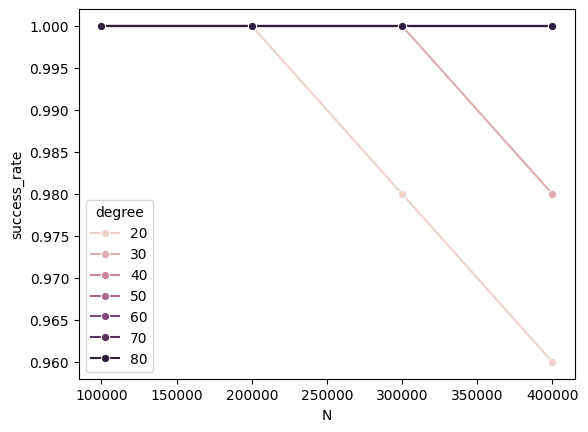

In [38]:
import seaborn as sns

b = matched_rows[matched_rows['beta'] == 0.5]
sns.lineplot(data=b, x="N", y="success_rate", hue="degree", marker="o")

In [9]:
x = 'N'
y = 'success_rate'
hue = 'degree'

beta = 0.1

plt.figure(figsize=(9,5))
sns.lineplot(data=agg_nd, x="N", y="success_rate", hue="degree", marker="o")
plt.xscale("log")
plt.ylim(0, 1)
plt.title("Success Rate vs N (mean over beta, k, h)")
plt.ylabel("Success rate")
plt.show()

,N,degree,beta,k,h,success_rate,avg_overhead,min_overhead,q1_overhead,median_overhead,q3_overhead,max_overhead,avg_latency,min_latency,q1_latency,median_latency,q3_latency,max_latency
0,100000,20,0.1,20,100,0.26,1733.75,91,1872.50,2000.0,2000.00,2000,49.269231,5,22.25,46.0,81.00,94
1,100000,20,0.1,20,200,0.58,2848.89,178,1793.50,3650.5,4000.00,4000,101.275862,9,49.00,94.5,154.00,197
2,100000,20,0.1,20,300,0.76,3290.81,115,1388.50,2960.0,5928.50,6000,122.184211,6,49.25,109.0,184.00,300
3,100000,20,0.1,20,400,0.76,4229.57,120,1462.25,3756.5,7769.50,8000,152.460526,6,65.75,131.0,233.00,397
4,100000,20,0.1,20,500,0.84,4301.19,180,1642.00,3318.0,6388.50,10000,161.285714,9,65.75,136.5,243.00,479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4699,400000,80,1.0,80,400,0.99,6959.81,217,1747.00,4348.5,8486.75,32000,84.313131,3,22.00,55.0,105.50,365
4700,400000,80,1.0,80,500,0.98,6826.37,300,2006.50,4347.5,8320.00,40000,77.397959,4,25.25,52.5,92.75,352
4701,400000,80,1.0,80,600,0.98,8947.73,171,2251.25,5541.0,11037.75,48000,102.367347,3,28.25,68.0,129.50,589
4702,400000,80,1.0,80,700,1.00,6955.76,158,1466.75,4741.0,9482.75,47557,87.450000,2,18.75,59.5,119.25,595


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su

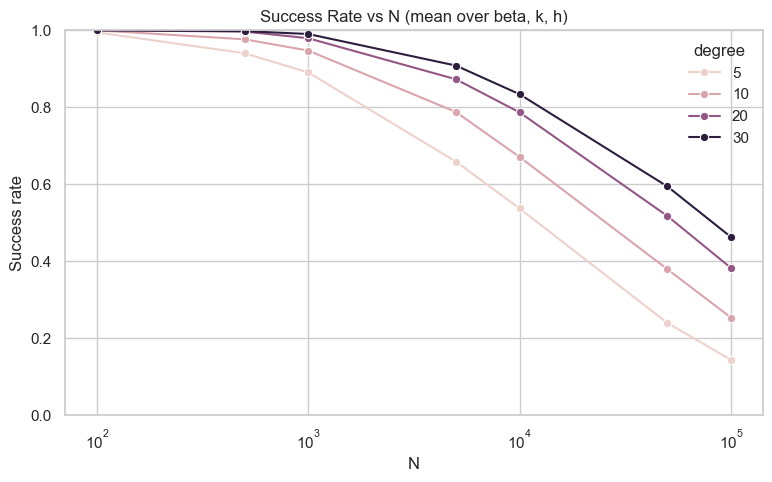

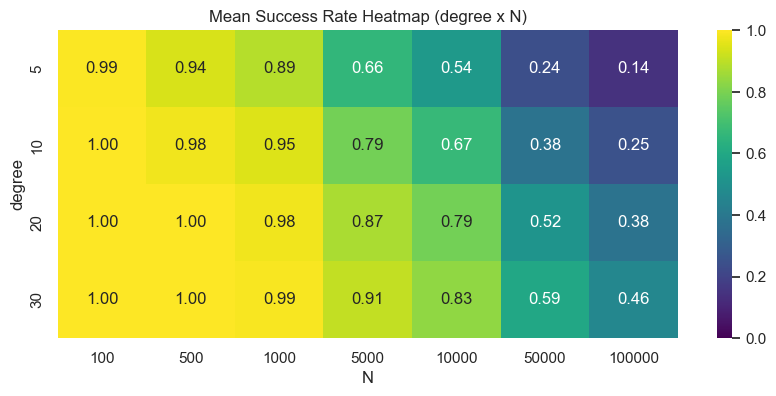

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su

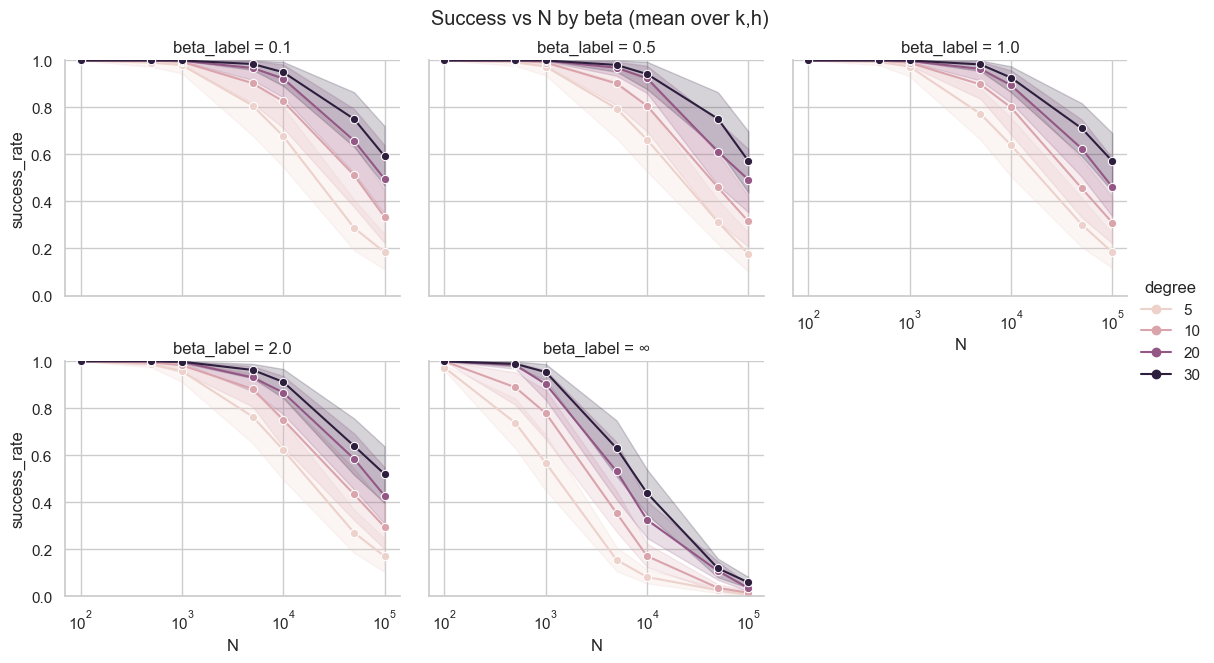

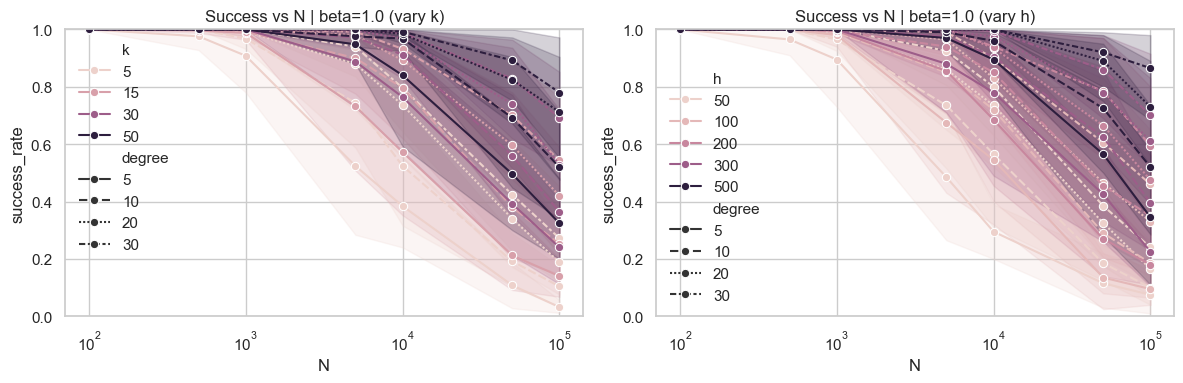

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# ---- copy + clean ----
df = results.copy()
for c in ["N", "degree", "k", "h", "success_rate", "avg_overhead", "avg_latency"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# beta for plotting (keep both numeric + label)
df["beta_num"] = df["beta"].replace(np.inf, np.nan)
df["beta_label"] = df["beta"].astype(str).replace({"inf": "∞"})

# optional: force sorted category order
beta_order = sorted([b for b in df["beta_label"].unique() if b != "∞"], key=float) + (["∞"] if "∞" in df["beta_label"].unique() else [])
df["beta_label"] = pd.Categorical(df["beta_label"], categories=beta_order, ordered=True)

# ----------------------------
# 1) Success rate vs N, colored by degree (averaged over beta,k,h)
# ----------------------------
agg_nd = (
    df.groupby(["N", "degree"], as_index=False)["success_rate"]
      .max()
      .sort_values(["degree", "N"])
)

plt.figure(figsize=(9,5))
sns.lineplot(data=agg_nd, x="N", y="success_rate", hue="degree", marker="o")
plt.xscale("log")
plt.ylim(0, 1)
plt.title("Success Rate vs N (mean over beta, k, h)")
plt.ylabel("Success rate")
plt.show()

# ----------------------------
# 2) Heatmap: N x degree -> mean success rate
# ----------------------------
pivot_nd = agg_nd.pivot(index="degree", columns="N", values="success_rate")
plt.figure(figsize=(10,4))
sns.heatmap(pivot_nd, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Mean Success Rate Heatmap (degree x N)")
plt.xlabel("N")
plt.ylabel("degree")
plt.show()

# ----------------------------
# 3) Interaction with beta: one panel per beta
# ----------------------------
g = sns.relplot(
    data=df,
    x="N", y="success_rate",
    hue="degree",
    col="beta_label",
    kind="line",
    estimator="mean",
    marker="o",
    col_wrap=3,
    height=3.2,
    aspect=1.2
)
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_ylim(0, 1)
g.fig.suptitle("Success vs N by beta (mean over k,h)", y=1.02)
plt.show()

# ----------------------------
# 4) Interactions with k and h (choose one beta for clarity, e.g. beta=1.0 or ∞)
# ----------------------------
beta_view = "1.0" if "1.0" in df["beta_label"].astype(str).unique() else str(df["beta_label"].dropna().iloc[0])
sub = df[df["beta_label"].astype(str) == beta_view]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=sub, x="N", y="success_rate", hue="k", style="degree", marker="o", estimator="mean", ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_ylim(0, 1)
axes[0].set_title(f"Success vs N | beta={beta_view} (vary k)")

sns.lineplot(data=sub, x="N", y="success_rate", hue="h", style="degree", marker="o", estimator="mean", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_ylim(0, 1)
axes[1].set_title(f"Success vs N | beta={beta_view} (vary h)")

plt.tight_layout()
plt.show()

In [32]:
results['beta'].unique()

array([0.1, 0.5, 1. , 2. , inf])

In [33]:
df = results[results['beta'] != np.inf].copy()

# example grouped view
grouped = (
    df.groupby(["N", "degree"], as_index=False)
    .agg(
        mean_success_rate=("success_rate", "mean"),
        max_success_rate=("success_rate", "max"),
        mean_overhead=("avg_overhead", "mean"),
        mean_latency=("avg_latency", "mean"),
    )
    .sort_values(["N", "degree"])
)

display(grouped)

,N,degree,mean_success_rate,max_success_rate,mean_overhead,mean_latency
0,100,5,1.00000,1.00,81.76775,4.694500
1,100,10,1.00000,1.00,47.39075,2.943500
2,100,20,1.00000,1.00,30.65325,2.201500
3,100,30,1.00000,1.00,22.40925,1.836250
4,500,5,0.99100,1.00,216.88525,13.400823
5,500,10,0.99850,1.00,125.78475,7.755321
6,500,20,1.00000,1.00,77.17600,4.670750
7,500,30,1.00000,1.00,58.26625,3.641750
8,1000,5,0.97150,1.00,362.79750,22.642663
9,1000,10,0.98950,1.00,198.01425,12.534816


In [ ]:
x = results["N"].unique()
y = ''

Rows at max success_rate (ties kept):


,N,degree,success_rate,beta,k,h,avg_overhead,avg_latency
0,100,5,1.0,0.1,5,50,27.44,5.96
1,100,5,1.0,0.1,5,100,33.04,7.02
2,100,5,1.0,0.1,5,200,29.16,6.32
3,100,5,1.0,0.1,5,300,27.48,5.90
4,100,5,1.0,0.1,5,500,29.10,6.22
...,...,...,...,...,...,...,...,...
2719,100000,30,1.0,0.1,50,500,3862.78,77.78
2734,100000,30,1.0,0.5,30,500,3784.04,126.64
2739,100000,30,1.0,0.5,50,500,3021.90,60.90
2758,100000,30,1.0,1.0,50,300,3034.04,61.12


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su

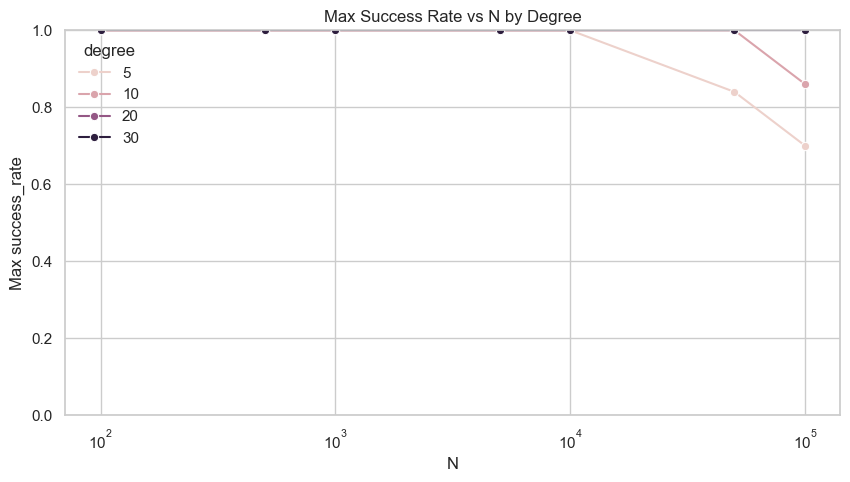

/var/folders/l0/2rrfy4gd3kg0bgbcyngl76h40000gn/T/ipykernel_19768/838273789.py:65: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


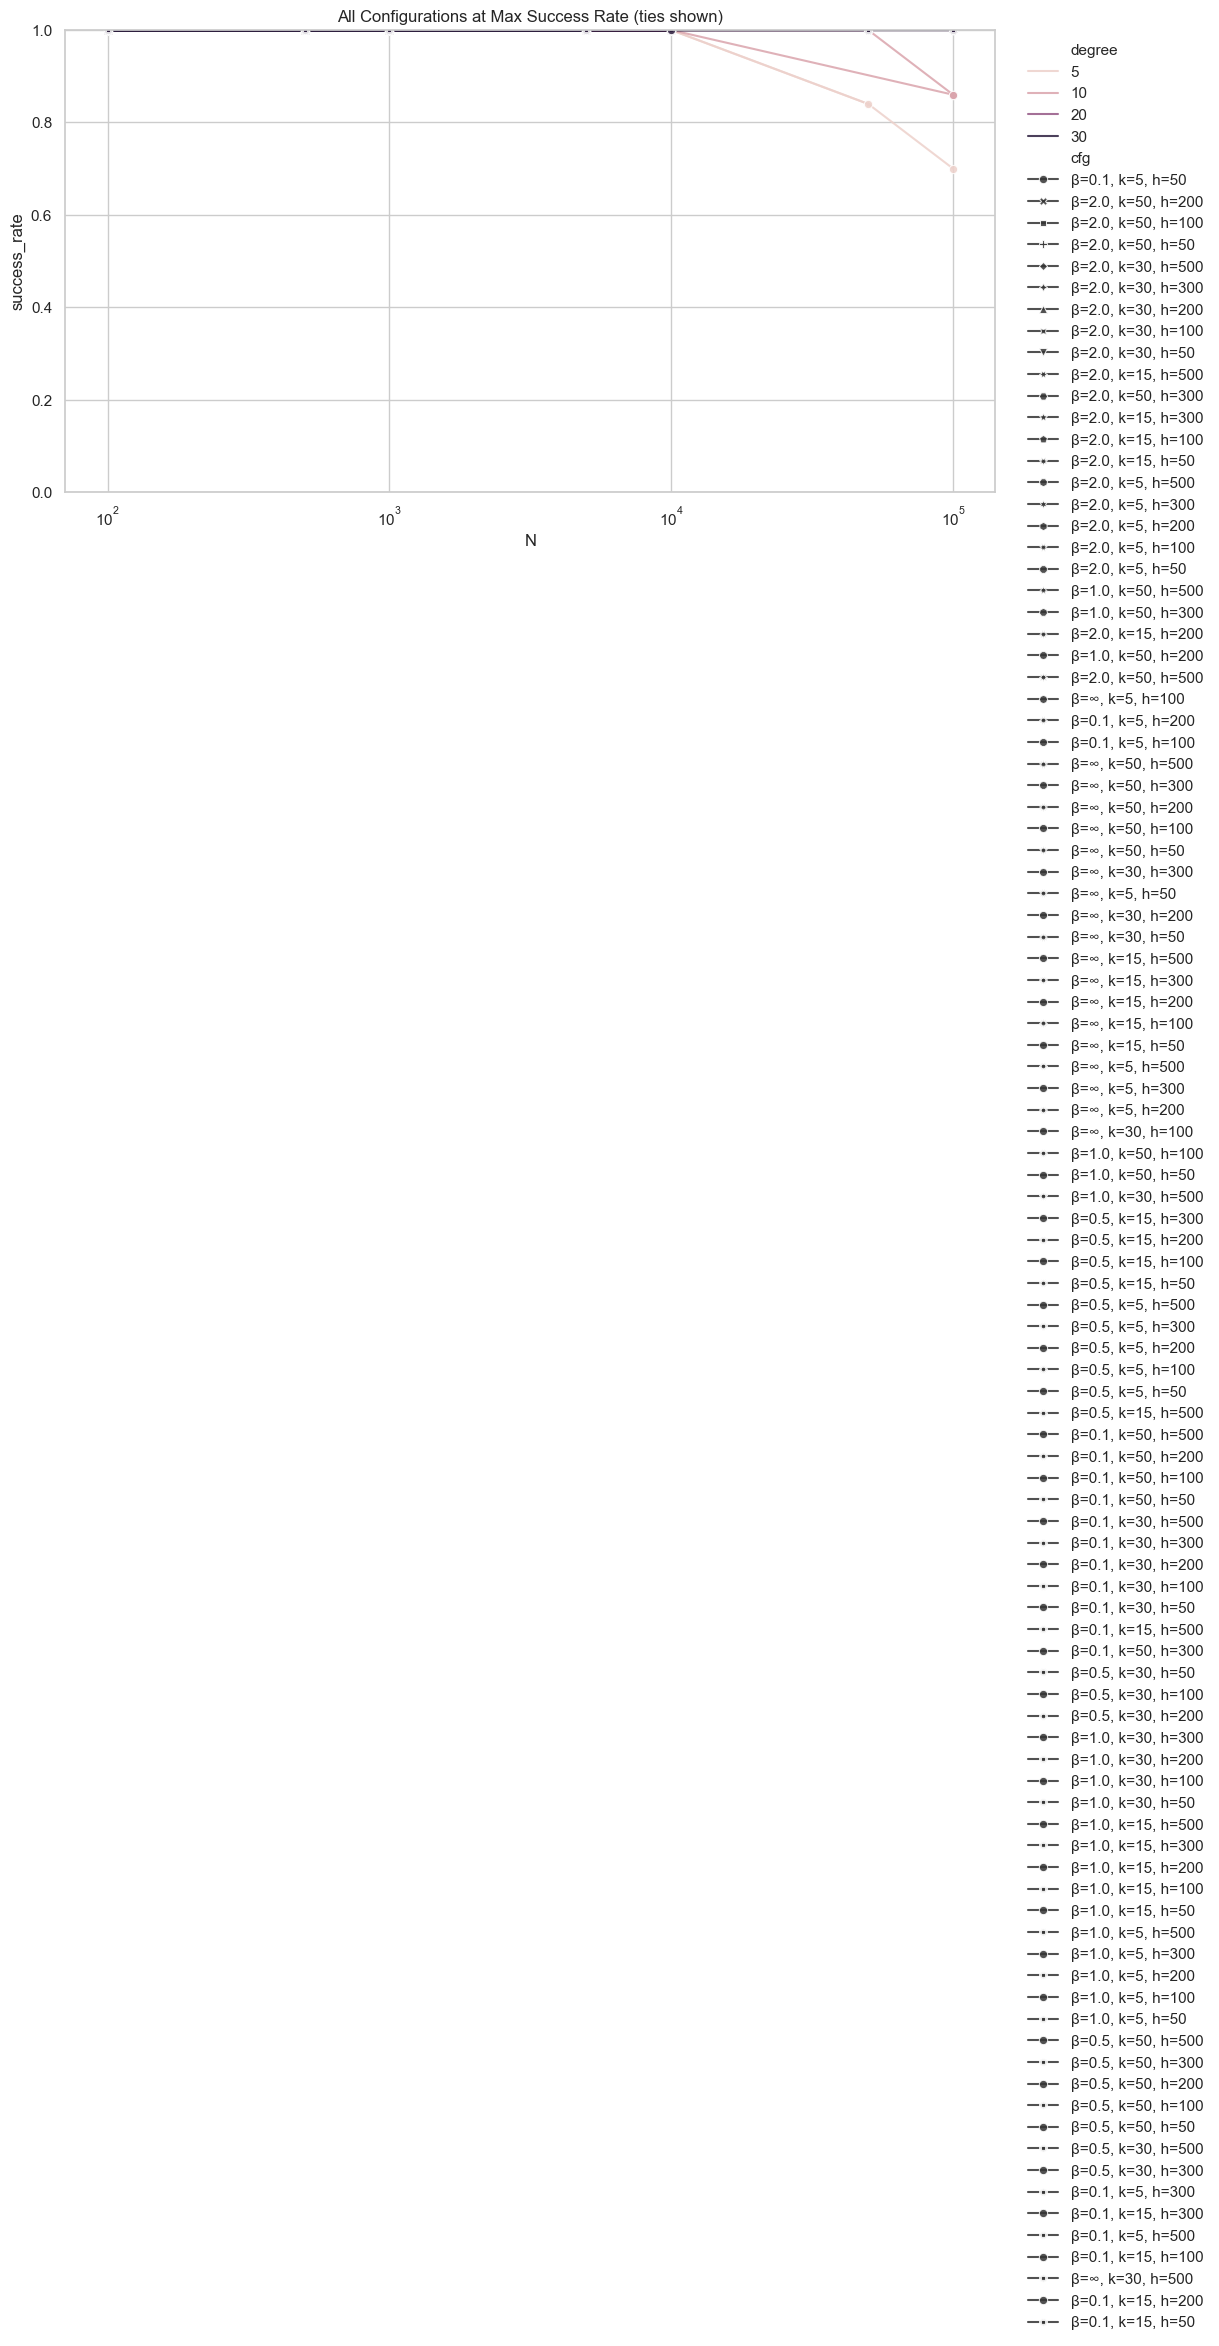

In [26]:
# ...existing code...
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = results.copy()
for c in ["N", "degree", "beta", "k", "h", "success_rate", "avg_overhead", "avg_latency"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 1) Keep ALL rows tied at max success_rate within each (N, degree)
group_cols = ["N", "degree"]
max_rows = df[df["success_rate"].eq(df.groupby(group_cols)["success_rate"].transform("max"))].copy()

# Optional pretty label for tied configurations
max_rows["beta_label"] = max_rows["beta"].replace(np.inf, np.nan).astype(str).replace({"nan": "∞"})
max_rows["cfg"] = max_rows.apply(
    lambda r: f"β={r['beta_label']}, k={int(r['k'])}, h={int(r['h'])}",
    axis=1
)

# 2) Show ALL tied maxima + unplotted variables
max_table = max_rows[
    ["N", "degree", "success_rate", "beta", "k", "h", "avg_overhead", "avg_latency"]
].sort_values(["N", "degree", "beta", "k", "h"])
print("Rows at max success_rate (ties kept):")
display(max_table)

# 3) Plot max-success envelope by (N, degree)
envelope = (
    max_rows.groupby(["N", "degree"], as_index=False)["success_rate"]
    .max()
    .sort_values(["degree", "N"])
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=envelope, x="N", y="success_rate", hue="degree", marker="o")
plt.xscale("log")
plt.ylim(0, 1)
plt.title("Max Success Rate vs N by Degree")
plt.ylabel("Max success_rate")
plt.show()

# 4) Plot tied-max configurations as separate lines (shows both/all ties)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=max_rows.sort_values("N"),
    x="N",
    y="success_rate",
    hue="degree",
    style="cfg",
    units="cfg",
    estimator=None,
    markers=True,
    dashes=False,
    alpha=0.85
)
plt.xscale("log")
plt.ylim(0, 1)
plt.title("All Configurations at Max Success Rate (ties shown)")
plt.ylabel("success_rate")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
# ...existing code...

# Attenuated Bloomfilters

In [13]:
import networkx as nx
import random
import math
from collections import deque

def build_random_network(num_nodes=10000, degree=20):
    """Builds a purely random unstructured graph."""
    return nx.random_regular_graph(degree, num_nodes)

def calculate_abf_metrics(m_mb, n_files, d_max, degree):
    """
    Calculates the mathematical False Positive Rate (P_fp) 
    and the total Memory Overhead per node.
    """
    m_bits = m_mb * 8 * 1024 * 1024
    
    # False positive probability: p = (1 - e^(-kn/m))^k
    # Optimal k = (m/n) * ln(2)
    k = (m_bits / n_files) * math.log(2)
    p_fp = (1 - math.exp(-k * n_files / m_bits)) ** k
    
    # Total memory per node (MB) = degree * d_max * filter_size_mb
    memory_mb = degree * d_max * m_mb
    
    return p_fp, memory_mb

def precompute_true_distances(G, targets):
    """
    Simulates omniscient knowledge of where the files actually are.
    Used exclusively to determine if a Bloom filter should return a True Positive.
    """
    distances = {node: float('inf') for node in G.nodes()}
    queue = deque()
    
    for t in targets:
        distances[t] = 0
        queue.append(t)
        
    while queue:
        current = queue.popleft()
        dist = distances[current]
        
        for neighbor in G.neighbors(current):
            if distances[neighbor] == float('inf'):
                distances[neighbor] = dist + 1
                queue.append(neighbor)
                
    return distances

def simulate_abf_routing(G, start_node, distances, d_max, p_fp):
    """
    Simulates a walker following the Bloom filter scent trail.
    If it hits a False Positive dead end, it backtracks.
    """
    stack = [start_node]
    visited = set([start_node])
    hops = 0
    
    while stack:
        current = stack[-1]
        
        # Target found!
        if distances[current] == 0:
            return True, hops
            
        hops += 1
        stepped = False
        
        # Check radar depths from 1 up to d_max
        for depth in range(1, d_max + 1):
            candidates = []
            for neighbor in G.neighbors(current):
                if neighbor in visited: 
                    continue
                
                # True Positive: The file is physically down this path
                if distances[neighbor] <= depth:
                    candidates.append(neighbor)
                # False Positive: The filter lies based on P_fp
                elif random.random() < p_fp:
                    candidates.append(neighbor)
            
            if candidates:
                # The walker takes the scent trail
                next_node = random.choice(candidates)
                visited.add(next_node)
                stack.append(next_node)
                stepped = True
                break # Break out of the depth loop to take the step
                
        # If no filters matched at any depth, we hit a dead end
        if not stepped:
            stack.pop() # Backtrack one hop
            
    return False, hops

def run_abf_sweep(G, num_nodes, iterations=200):
    # Network Constraints
    capacity_files = 100000 
    d_max = 3
    degree = 20
    num_replicas = 8
    
    # Filter sizes to test in Megabytes (MB)
    filter_sizes = [0.1, 0.25, 0.5, 1.0, 2.0]
    
    print(f"{'Single Filter':<15} | {'Node Memory':<13} | {'False Pos %':<12} | {'Avg Overhead'}")
    print("-" * 60)
    
    for m_mb in filter_sizes:
        p_fp, memory_mb = calculate_abf_metrics(m_mb, capacity_files, d_max, degree)
        
        total_hops = 0
        nodes_list = list(G.nodes())
        
        for _ in range(iterations):
            # 1. Randomly drop 8 replicas in the unstructured network
            targets = random.sample(nodes_list, num_replicas)
            
            # 2. Precompute true shortest paths for the simulation logic
            distances = precompute_true_distances(G, targets)
            
            # 3. Random start node
            start_node = random.choice(nodes_list)
            while start_node in targets:
                start_node = random.choice(nodes_list)
                
            # 4. Route the Read request
            success, hops = simulate_abf_routing(G, start_node, distances, d_max, p_fp)
            total_hops += hops
            
        avg_hops = total_hops / iterations
        print(f"{m_mb:<12} MB | {memory_mb:<10.1f} MB | {p_fp:<12.2%} | {avg_hops:.1f} hops")

if __name__ == "__main__":
    N = [100, 500, 1000, 5000, 10000, 25000, 50000, 100000]
    
    for n in N:
        print(f"Generating {n}-node random unstructured network...")
        uvr_graph = build_random_network(num_nodes=n, degree=20)
        
        print("Running ABF parameter sweep...\n")
        run_abf_sweep(uvr_graph, num_nodes=n, iterations=200)

Generating 100-node random unstructured network...
Running ABF parameter sweep...

Single Filter   | Node Memory   | False Pos %  | Avg Overhead
------------------------------------------------------------
0.1          MB | 6.0        MB | 1.78%        | 7.7 hops
0.25         MB | 15.0       MB | 0.00%        | 8.3 hops
0.5          MB | 30.0       MB | 0.00%        | 7.8 hops
1.0          MB | 60.0       MB | 0.00%        | 7.6 hops
2.0          MB | 120.0      MB | 0.00%        | 9.0 hops
Generating 500-node random unstructured network...
Running ABF parameter sweep...

Single Filter   | Node Memory   | False Pos %  | Avg Overhead
------------------------------------------------------------
0.1          MB | 6.0        MB | 1.78%        | 5.4 hops
0.25         MB | 15.0       MB | 0.00%        | 5.3 hops
0.5          MB | 30.0       MB | 0.00%        | 5.1 hops
1.0          MB | 60.0       MB | 0.00%        | 5.1 hops
2.0          MB | 120.0      MB | 0.00%        | 5.7 hops
Generati

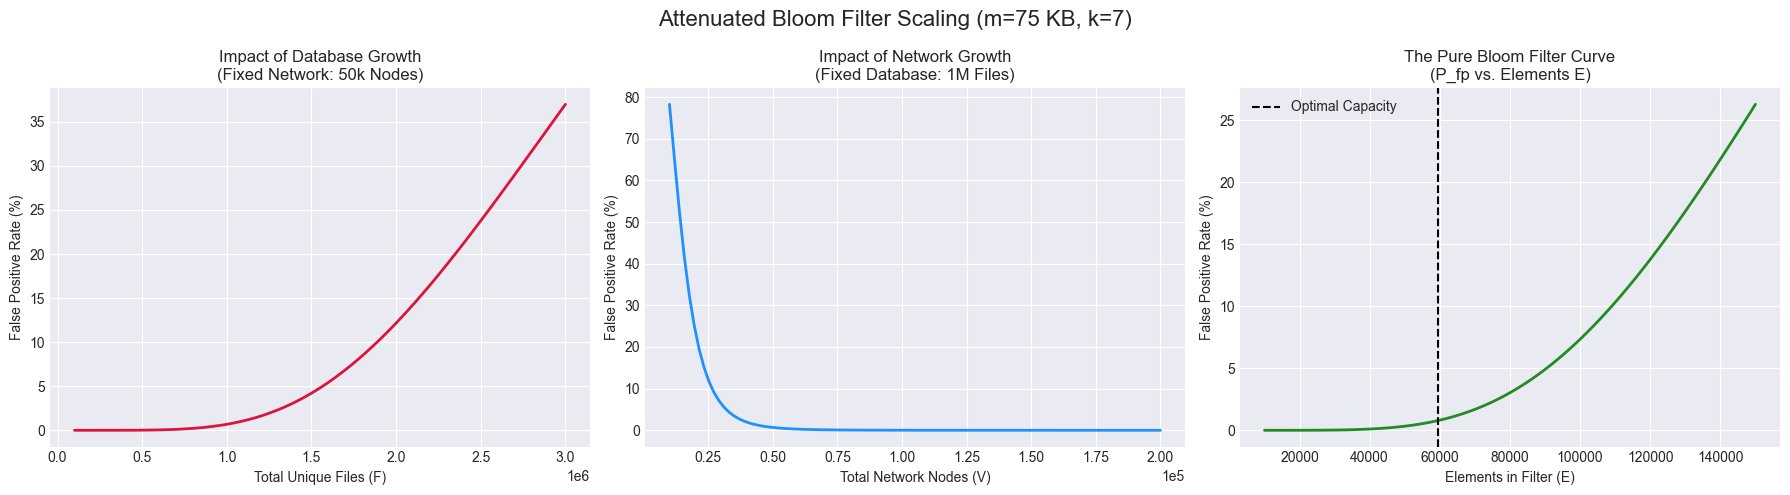

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. System Constants ---
D = 20          # Node degree (peers)
R = 8           # Number of replicas per file
depth = 3       # Looking at the deepest filter (BF_3)
nodes_covered = (D - 1)**(depth - 1) # ~361 nodes in a 3-hop branch

# --- 2. Filter Constraints ---
# We use a highly optimized ~73 KB filter to make the curves visible
m_bits = 600_000 
k_hashes = 7

# Baseline values for the hold-steady variables
V_baseline = 50_000      # 50k nodes
F_baseline = 1_000_000   # 1 Million files

# --- 3. Mathematical Functions ---
def calculate_elements(F, V):
    """Calculates E: The actual number of file chunks inside the BF_3 filter."""
    files_per_node = (F * R) / V
    return nodes_covered * files_per_node

def calculate_pfp(E, m, k):
    """Calculates the False Positive Rate based on inserted elements E."""
    # Using np.exp for vectorized array calculations
    return (1 - np.exp(-k * E / m))**k

# --- 4. Generate Data Arrays ---
# Scenario A: Database grows, Network stays at 50k nodes
F_array = np.linspace(100_000, 3_000_000, 100)
E_scenario_A = calculate_elements(F_array, V_baseline)
Pfp_scenario_A = calculate_pfp(E_scenario_A, m_bits, k_hashes)

# Scenario B: Network grows, Database stays at 1 Million files
V_array = np.linspace(10_000, 200_000, 100)
E_scenario_B = calculate_elements(F_baseline, V_array)
Pfp_scenario_B = calculate_pfp(E_scenario_B, m_bits, k_hashes)

# Scenario C: The Pure Mathematical Bloom Filter Curve
E_array = np.linspace(10_000, 150_000, 100)
Pfp_scenario_C = calculate_pfp(E_array, m_bits, k_hashes)

# --- 5. Plotting ---
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Attenuated Bloom Filter Scaling (m={m_bits/8000:.0f} KB, k={k_hashes})', fontsize=16)

# Plot 1: P_fp vs Total Files (F)
axes[0].plot(F_array, Pfp_scenario_A * 100, color='crimson', linewidth=2)
axes[0].set_title('Impact of Database Growth\n(Fixed Network: 50k Nodes)')
axes[0].set_xlabel('Total Unique Files (F)')
axes[0].set_ylabel('False Positive Rate (%)')
axes[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))

# Plot 2: P_fp vs Network Size (V)
axes[1].plot(V_array, Pfp_scenario_B * 100, color='dodgerblue', linewidth=2)
axes[1].set_title('Impact of Network Growth\n(Fixed Database: 1M Files)')
axes[1].set_xlabel('Total Network Nodes (V)')
axes[1].set_ylabel('False Positive Rate (%)')
axes[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))

# Plot 3: P_fp vs Filter Elements (E)
axes[2].plot(E_array, Pfp_scenario_C * 100, color='forestgreen', linewidth=2)
axes[2].set_title('The Pure Bloom Filter Curve\n(P_fp vs. Elements E)')
axes[2].set_xlabel('Elements in Filter (E)')
axes[2].set_ylabel('False Positive Rate (%)')
axes[2].axvline(x=(m_bits/k_hashes)*np.log(2), color='black', linestyle='--', label='Optimal Capacity')
axes[2].legend()

plt.tight_layout()
plt.show()

# Hybrid Topology with 1D-Ring

In [11]:
import networkx as nx
import random

MAX_ID = 2**256

def circular_distance(id1, id2):
    """Calculates the shortest distance around the 1D circular number line."""
    diff = abs(id1 - id2)
    return min(diff, MAX_ID - diff)

def build_hybrid_ring(num_nodes=50000, total_degree=20):
    """
    Builds a hybrid topology: a strict 1D base ring for guaranteed routing,
    plus purely random long-range connections for unstructured resilience.
    """
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))
    
    # 1. Build the Safety Net (The Base 1D Ring)
    for i in range(num_nodes):
        G.add_edge(i, (i + 1) % num_nodes)
        
    # 2. Add the Random Fast Lanes
    # We want each node to reach roughly 'total_degree' edges
    random_edges_needed = (total_degree - 2) * num_nodes // 2
    
    edges_added = 0
    while edges_added < random_edges_needed:
        u = random.randint(0, num_nodes - 1)
        v = random.randint(0, num_nodes - 1)
        
        # Avoid self-loops and duplicate edges
        if u != v and not G.has_edge(u, v):
            G.add_edge(u, v)
            edges_added += 1
            
    return G

def get_contiguous_replicas(num_nodes, center_node, num_replicas=8):
    """Locates the 8 replicas natively clustered along the 1D gradient."""
    replicas = set()
    offset = 0
    while len(replicas) < num_replicas:
        replicas.add((center_node + offset) % num_nodes)
        if len(replicas) < num_replicas:
            replicas.add((center_node - offset) % num_nodes)
        offset += 1
    return replicas

def strictly_greedy_search(G, start_node, target_nodes, cid, node_ids):
    """
    A single walker always choosing the absolute best 1D distance neighbor.
    Because of the base ring, this will NEVER hit a dead end.
    """
    current = start_node
    hops = 0
    
    while True:
        if current in target_nodes:
            return True, hops
            
        neighbors = list(G.neighbors(current))
        best_neighbor = min(neighbors, key=lambda n: circular_distance(node_ids[n], cid))
        
        current = best_neighbor
        hops += 1

def run_hybrid_simulation(G, node_ids, num_nodes, iterations=1000):
    nodes = list(G.nodes())
    successes = 0
    total_hops = 0
    
    print(f"{'Simulation':<12} | {'k Walkers':<10} | {'Success Rate':<15} | {'Avg Overhead / Latency'}")
    print("-" * 65)

    for _ in range(iterations):
        cid = random.getrandbits(256)
        ideal_node = min(nodes, key=lambda n: circular_distance(node_ids[n], cid))
        target_replicas = get_contiguous_replicas(num_nodes, ideal_node, num_replicas=8)
        
        start_node = random.choice(nodes)
        while start_node in target_replicas:
            start_node = random.choice(nodes)
            
        # Single greedy walker
        success, hops = strictly_greedy_search(G, start_node, target_replicas, cid, node_ids)
        
        if success:
            successes += 1
            total_hops += hops
            
    print(f"{'Hybrid Ring':<12} | {1:<10} | {successes/iterations:<15.0%} | {total_hops/iterations:.1f} hops")

if __name__ == "__main__":
    N = 50000
    
    print(f"Generating {N}-node Hybrid Ring (Degree=20)...")
    uvr_graph = build_hybrid_ring(num_nodes=N, total_degree=20)
    
    # IDs mapped directly to physical ring position
    step = MAX_ID // N
    ids = {i: i * step for i in range(N)}
    
    print("Running greedy routing simulation...\n")
    run_hybrid_simulation(uvr_graph, ids, num_nodes=N, iterations=1000)

Generating 50000-node Hybrid Ring (Degree=20)...
Running greedy routing simulation...

Simulation   | k Walkers  | Success Rate    | Avg Overhead / Latency
-----------------------------------------------------------------
Hybrid Ring  | 1          | 100%            | 42.5 hops


Two Tuple Space layers:
- application layer (permissioned) p2pTS
- storage layer (anyone can contribute) DHT-TS

centralized DHT routes TS (Gateway)

concurrency resolution is not supported by current DHT

Networked Data Representation 
<device ID, data> --> <CID, data>

Storage --> RDMS

lose partition, how do you resynchronize?